<a href="https://colab.research.google.com/github/phongsitt9/motor-glm-pricing/blob/main/03_burning_cost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Burning Cost = Total Losses ÷ Total Exposure
— โดยเฉลี่ยแล้ว คนในกลุ่มนี้ทำให้บริษัทประกันเสียเงิน กี่ยูโรต่อปี
เป็น method พื้นฐานที่ actuarial ใช้จริงในการ price insurance
ก่อนจะ fit GLM ต้องเข้าใจ burning cost ของแต่ละ risk segment ก่อน

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('outputs', exist_ok=True)
df = pd.read_csv("clean_data.csv")

In [ ]:
def burning_cost(data, group_col):
    return (data.groupby(group_col, observed=False)
                .apply(lambda x: pd.Series({
                    "TotalLoss":     x["ClaimAmount"].sum(),
                    "TotalExposure": x["Exposure"].sum(),
                    "ClaimCount":    x["ClaimNb"].sum(),
                    "PolicyCount":   len(x),
                    "BurningCost":   x["ClaimAmount"].sum() / x["Exposure"].sum()
                }), include_groups=False)
                .reset_index()
                .round(2))

bc_area = burning_cost(df, "Area")
display(bc_area)

/tmp/ipykernel_1263/90900004.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,Area,TotalLoss,TotalExposure,ClaimCount,PolicyCount,BurningCost
0,A,2438218.58,16610.51,2735.0,25727.0,146.79
1,B,1461248.98,11382.87,2003.0,17937.0,128.37
2,C,5585265.67,26401.45,4845.0,42444.0,211.55
3,D,3171600.68,19106.19,3828.0,32331.0,166.00
4,E,2951069.18,13485.41,3272.0,24049.0,218.83
5,F,201640.53,1560.21,533.0,3068.0,129.24


In [ ]:
df["VehAgeGroup"] = pd.cut(df["VehAge"],
    bins=[-1, 1, 3, 6, 10, 100],
    labels=["0-1yr", "2-3yr", "4-6yr", "7-10yr", "10+yr"])

bc_vehage = burning_cost(df, "VehAgeGroup")
display(bc_vehage)

/tmp/ipykernel_1263/90900004.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (data.groupby(group_col)
/tmp/ipykernel_1263/90900004.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,VehAgeGroup,TotalLoss,TotalExposure,ClaimCount,PolicyCount,BurningCost
0,0-1yr,2115377.69,11513.84,5576.0,26621.0,183.72
1,2-3yr,1984984.62,11416.31,1904.0,17333.0,173.87
2,4-6yr,2616869.47,17197.18,2935.0,25693.0,152.17
3,7-10yr,3546097.09,21140.61,3395.0,32702.0,167.74
4,10+yr,5545714.75,27278.70,3406.0,43207.0,203.30


In [ ]:
df["AgeGroup"] = pd.cut(df["DrivAge"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])

bc_drivage = burning_cost(df, "AgeGroup")
display(bc_drivage)

/tmp/ipykernel_1263/90900004.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (data.groupby(group_col)
/tmp/ipykernel_1263/90900004.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,AgeGroup,TotalLoss,TotalExposure,ClaimCount,PolicyCount,BurningCost
0,18-25,3055568.06,5072.96,1198.0,10937.0,602.32
1,26-35,3191563.62,18985.19,3089.0,34602.0,168.11
2,36-45,3028601.55,20645.10,3822.0,34222.0,146.70
3,46-55,3680976.02,22032.61,4561.0,34839.0,167.07
4,56-65,1150154.45,11202.05,2273.0,16808.0,102.67
5,65+,1702179.92,10608.46,2273.0,14147.0,160.45


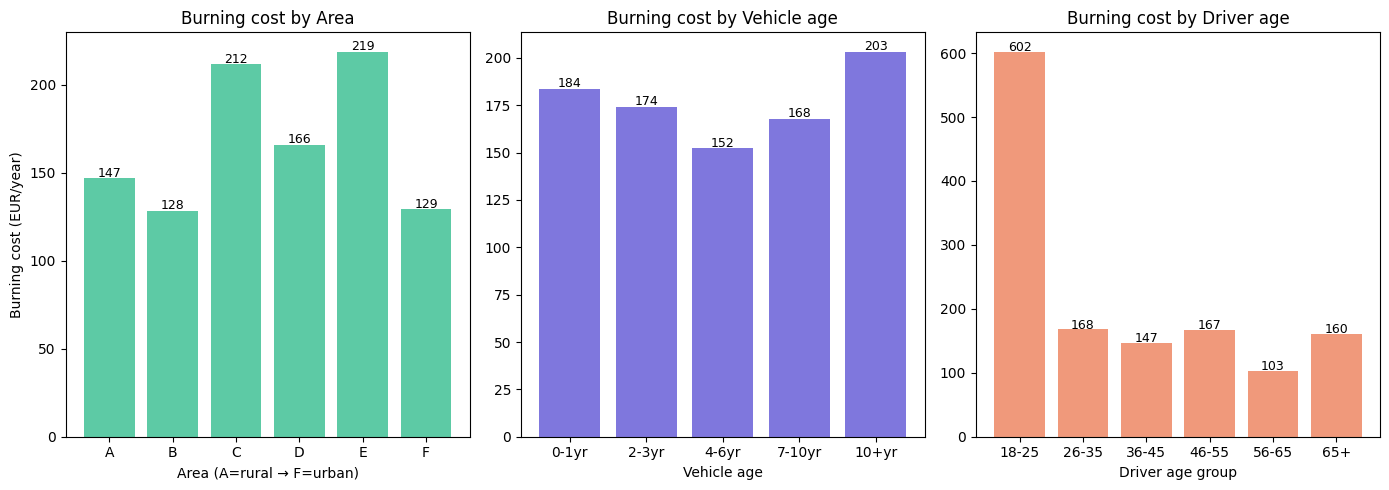

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Area
axes[0].bar(bc_area["Area"], bc_area["BurningCost"], color="#5DCAA5")
axes[0].set_title("Burning cost by Area")
axes[0].set_xlabel("Area (A=rural → F=urban)")
axes[0].set_ylabel("Burning cost (EUR/year)")
for i, (_, row) in enumerate(bc_area.iterrows()):
    axes[0].text(i, row["BurningCost"] + 1,
                 f"{row['BurningCost']:.0f}", ha="center", fontsize=9)

# VehAge
axes[1].bar(bc_vehage["VehAgeGroup"].astype(str),
            bc_vehage["BurningCost"], color="#7F77DD")
axes[1].set_title("Burning cost by Vehicle age")
axes[1].set_xlabel("Vehicle age")
for i, (_, row) in enumerate(bc_vehage.iterrows()):
    axes[1].text(i, row["BurningCost"] + 1,
                 f"{row['BurningCost']:.0f}", ha="center", fontsize=9)

# DrivAge
axes[2].bar(bc_drivage["AgeGroup"].astype(str),
            bc_drivage["BurningCost"], color="#F0997B")
axes[2].set_title("Burning cost by Driver age")
axes[2].set_xlabel("Driver age group")
for i, (_, row) in enumerate(bc_drivage.iterrows()):
    axes[2].text(i, row["BurningCost"] + 1,
                 f"{row['BurningCost']:.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("outputs/burning_cost_charts.png", dpi=150)
plt.show()